# Titanic Missing Values Handling and Exploratory Data Analysis

**Academic Minor Project**  
**Branch:** B.E. Artificial Intelligence and Data Science (3rd Year)  
**Focus:** Data Exploration, Missing Value Detection & Handling, Data Cleaning, and Statistical Visualization using Python.


## 2. Introduction

### What is the Titanic Dataset?
The Titanic dataset is one of the most famous datasets in data science. It contains demographic and travel details of passengers aboard the RMS Titanic, which tragically sank on April 15, 1912, after colliding with an iceberg.

### Why is Data Cleaning Important?
In real-world data science projects, raw datasets are rarely clean. They often contain missing values, inconsistent formats, noise, or improper data types. Feeding raw, uncleaned data into analytical models leads to inaccurate statistical conclusions and skewed machine learning predictions.

### Why do Missing Values Need to be Handled?
Missing data can introduce bias, distort data distributions, and reduce sample statistical power. Handling missing values systematically (e.g., using median imputation for numerical data and mode imputation for categorical data) ensures dataset completeness and analytical reliability.

### Aim of this Project
This project aims to demonstrate end-to-end data cleaning, missing-value detection, statistical analysis, demographic exploratory analysis, and feature engineering on the Titanic dataset using Python.


## 3. Problem Statement

Real-world datasets frequently contain incomplete records due to collection errors, non-responses, or system failures. In the Titanic dataset, key attributes like passenger age, cabin location, and port of embarkation contain missing values.

The challenge addressed in this project is to:
1. Accurately detect missing values and calculate their percentage contribution.
2. Determine appropriate imputation strategies (mean vs. median vs. mode vs. column removal).
3. Apply both Pandas and Scikit-Learn `SimpleImputer` techniques to construct a clean dataset suitable for data-driven analysis.


## 4. Objectives

- Explore the Titanic dataset structure and data types.
- Identify and quantify missing values.
- Calculate missing-value percentages across all columns.
- Visualize missing data patterns using heatmaps.
- Analyze passenger demographics (gender, age distribution, class).
- Investigate passenger survival rates across demographic groups.
- Analyze ticket fare distributions.
- Perform family relationship analysis and create `family_size` feature.
- Perform median imputation for missing numerical data (`age`).
- Perform mode imputation for missing categorical data (`embarked`, `embark_town`).
- Demonstrate Scikit-Learn `SimpleImputer` for standardized imputation.
- Remove columns with excessive missingness (`deck`).
- Compare dataset state before vs. after data cleaning.
- Export the final cleaned dataset as `titanic_cleaned.csv`.


## 5. Tools and Technologies

- **Programming Language:** Python 3.x
- **Environment:** Jupyter Notebook / Interactive Environment
- **Data Manipulation:** Pandas, NumPy
- **Data Visualization:** Matplotlib, Seaborn
- **Machine Learning Tools:** Scikit-Learn (`SimpleImputer`)
- **Web Dashboard:** Streamlit


In [1]:
# Step 6: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.impute import SimpleImputer

# Display configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid')
print('Libraries successfully imported!')


Libraries successfully imported!


In [2]:
# Step 7: Load Dataset with Fallback
csv_path = 'data/titanic.csv'

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f"Successfully loaded local dataset from '{csv_path}'!")
else:
    print('Local dataset not found. Loading fallback dataset from GitHub repository...')
    url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'
    df = pd.read_csv(url)
    # Save locally for future offline runs
    os.makedirs('data', exist_ok=True)
    df.to_csv(csv_path, index=False)
    print('Fallback dataset loaded and cached locally!')

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.head()


Successfully loaded local dataset from 'data/titanic.csv'!
Dataset Shape: 891 rows, 15 columns



,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Step 8: Dataset Overview
print('--- Dataset Shape ---')
print(df.shape)

print('\n--- Column Names ---')
print(df.columns.tolist())

print('\n--- Dataset Info ---')
df.info()


--- Dataset Shape ---
(891, 15)

--- Column Names ---
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 

In [4]:
# Step 9: Basic Data Exploration
print('--- First 5 Rows ---')
display(df.head())

print('\n--- Last 5 Rows ---')
display(df.tail())

print('\n--- Numerical Summary Statistics ---')
display(df.describe())

print('\n--- Categorical Summary Statistics ---')
display(df.describe(include='object'))


--- First 5 Rows ---


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



--- Last 5 Rows ---


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True



--- Numerical Summary Statistics ---


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



--- Categorical Summary Statistics ---


,sex,embarked,class,who,deck,embark_town,alive
count,891,889,891,891,203,889,891
unique,2,3,3,3,7,3,2
top,male,S,Third,man,C,Southampton,no
freq,577,644,491,537,59,644,549


In [5]:
# Step 10: Detailed Statistical Analysis for Key Numerical Features
num_cols = ['age', 'fare', 'sibsp', 'parch']

stats_df = pd.DataFrame({
    'Count': df[num_cols].count(),
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Std Dev': df[num_cols].std(),
    'Min': df[num_cols].min(),
    '25% (Q1)': df[num_cols].quantile(0.25),
    '50% (Q2)': df[num_cols].quantile(0.50),
    '75% (Q3)': df[num_cols].quantile(0.75),
    'Max': df[num_cols].max()
})

display(stats_df.round(2))


,Count,Mean,Median,Std Dev,Min,25% (Q1),50% (Q2),75% (Q3),Max
age,714,29.70,28.00,14.53,0.42,20.12,28.00,38.0,80.00
fare,891,32.20,14.45,49.69,0.00,7.91,14.45,31.0,512.33
sibsp,891,0.52,0.00,1.10,0.00,0.00,0.00,1.0,8.00
parch,891,0.38,0.00,0.81,0.00,0.00,0.00,0.0,6.00


In [6]:
# Step 11: Missing Value Detection & Percentage Calculation
missing_count = df.isnull().sum()
total_rows = len(df)
missing_percentage = (missing_count / total_rows) * 100

missing_summary = pd.DataFrame({
    'Missing Values': missing_count,
    'Missing Percentage (%)': missing_percentage.round(2)
}).sort_values(by='Missing Values', ascending=False)

print('--- Missing Values Table ---')
display(missing_summary)


--- Missing Values Table ---


,Missing Values,Missing Percentage (%)
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22
sex,0,0.00
pclass,0,0.00
survived,0,0.00
fare,0,0.00
parch,0,0.00
sibsp,0,0.00


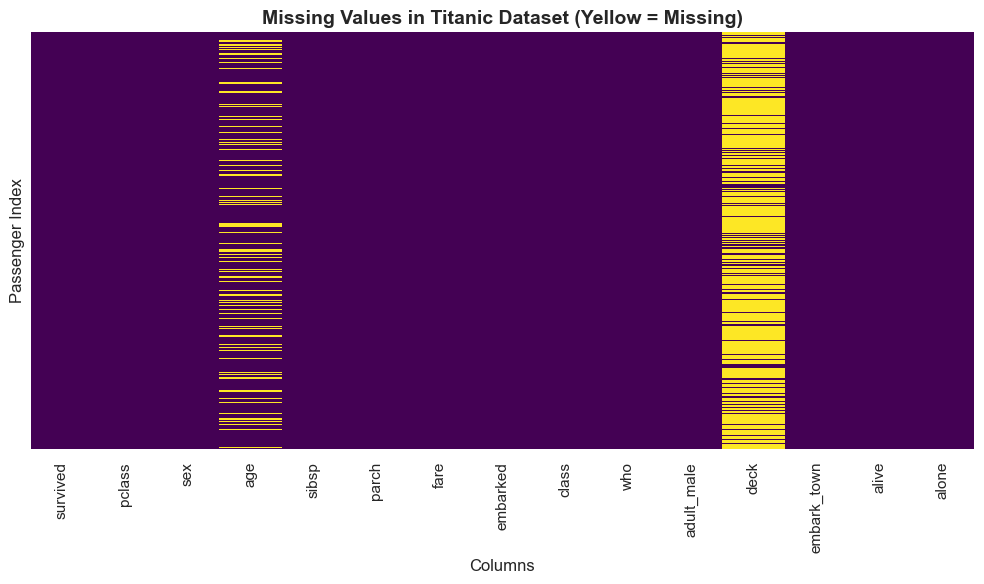

In [7]:
# Step 12: Missing Value Visualization (Heatmap - Plot 1)
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values in Titanic Dataset (Yellow = Missing)', fontsize=14, fontweight='bold')
plt.xlabel('Columns')
plt.ylabel('Passenger Index')
plt.tight_layout()
plt.show()


## 13. Passenger Demographic Analysis

Passenger demographic factors such as **Gender (Sex)**, **Age**, and **Passenger Class (Pclass)** provide crucial insights into the passenger profile on board the Titanic and played a major role in determining survival probability.


C:\Users\NAYANA H N\AppData\Local\Temp\ipykernel_30340\3104125765.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='sex', palette='pastel')


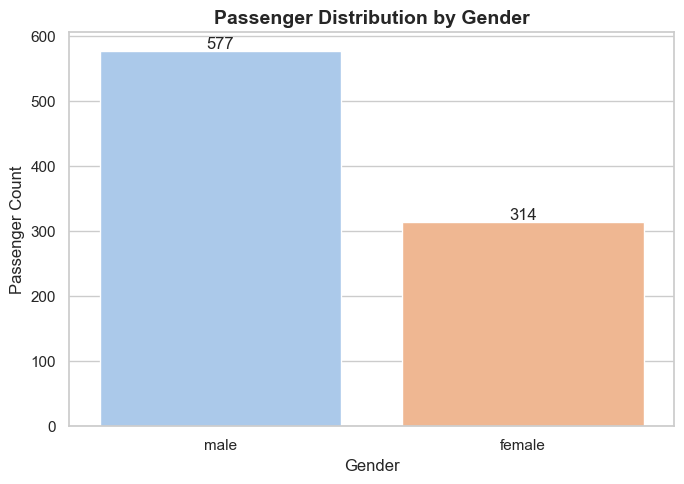

In [8]:
# Step 14: Gender Distribution Plot (Plot 2)
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='sex', palette='pastel')
plt.title('Passenger Distribution by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Passenger Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


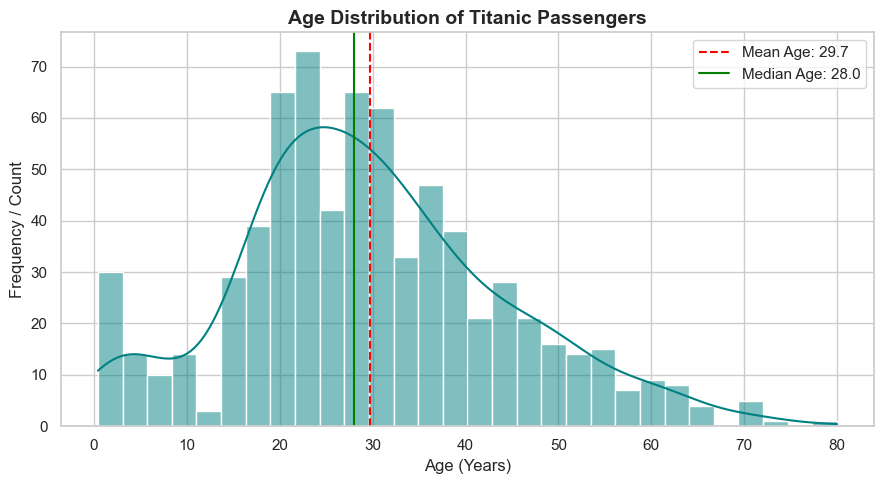

In [9]:
# Step 15: Age Distribution Histogram with KDE (Plot 3)
plt.figure(figsize=(9, 5))
sns.histplot(df['age'].dropna(), kde=True, bins=30, color='teal')
plt.title('Age Distribution of Titanic Passengers', fontsize=14, fontweight='bold')
plt.xlabel('Age (Years)')
plt.ylabel('Frequency / Count')
plt.axvline(df['age'].mean(), color='red', linestyle='--', label=f"Mean Age: {df['age'].mean():.1f}")
plt.axvline(df['age'].median(), color='green', linestyle='-', label=f"Median Age: {df['age'].median():.1f}")
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\NAYANA H N\AppData\Local\Temp\ipykernel_30340\814108920.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='pclass', palette='Set2')


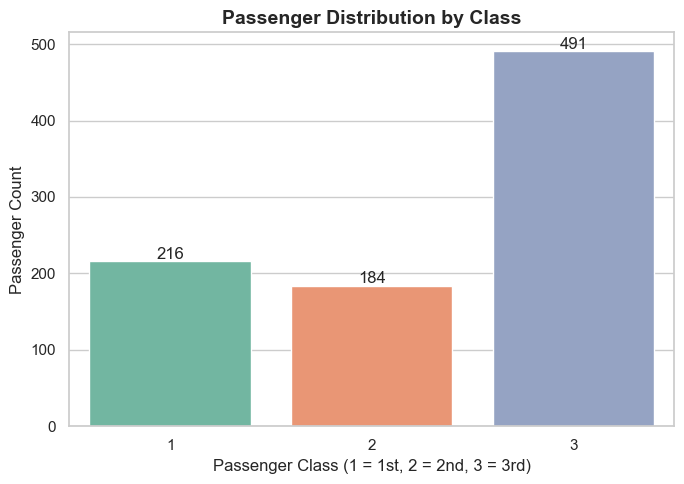

In [10]:
# Step 16: Passenger Class Distribution Plot (Plot 4)
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='pclass', palette='Set2')
plt.title('Passenger Distribution by Class', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)')
plt.ylabel('Passenger Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


C:\Users\NAYANA H N\AppData\Local\Temp\ipykernel_30340\2198394256.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='survived', palette='Set1')


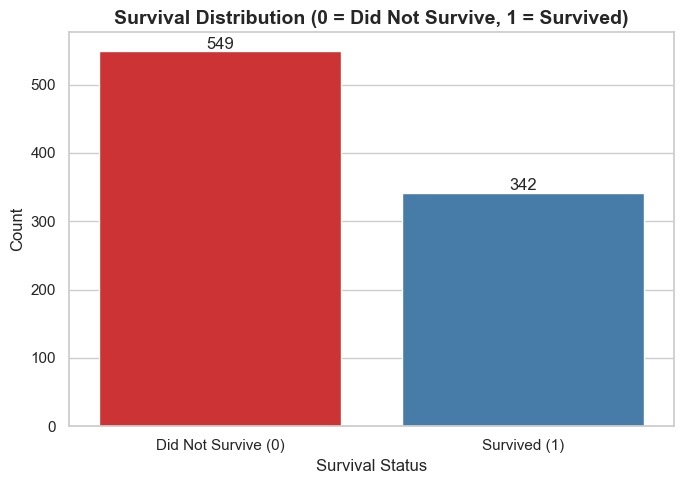

In [11]:
# Step 17: Overall Survival Distribution Plot (Plot 5)
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='survived', palette='Set1')
plt.title('Survival Distribution (0 = Did Not Survive, 1 = Survived)', fontsize=14, fontweight='bold')
plt.xlabel('Survival Status')
plt.ylabel('Count')
plt.xticks([0, 1], ['Did Not Survive (0)', 'Survived (1)'])

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


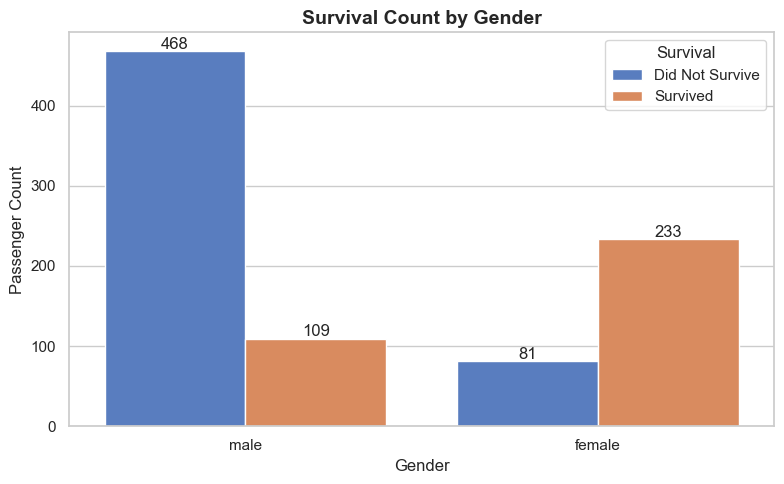

In [12]:
# Step 18: Gender vs Survival Analysis (Plot 6)
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='sex', hue='survived', palette='muted')
plt.title('Survival Count by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Passenger Count')
plt.legend(title='Survival', labels=['Did Not Survive', 'Survived'])

for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


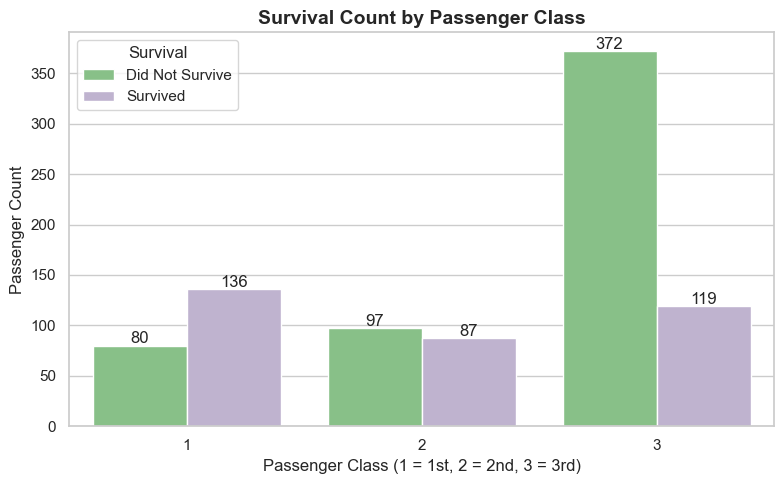

In [13]:
# Step 19: Passenger Class vs Survival Analysis (Plot 7)
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='pclass', hue='survived', palette='Accent')
plt.title('Survival Count by Passenger Class', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)')
plt.ylabel('Passenger Count')
plt.legend(title='Survival', labels=['Did Not Survive', 'Survived'])

for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


--- Ticket Fare Description ---
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64


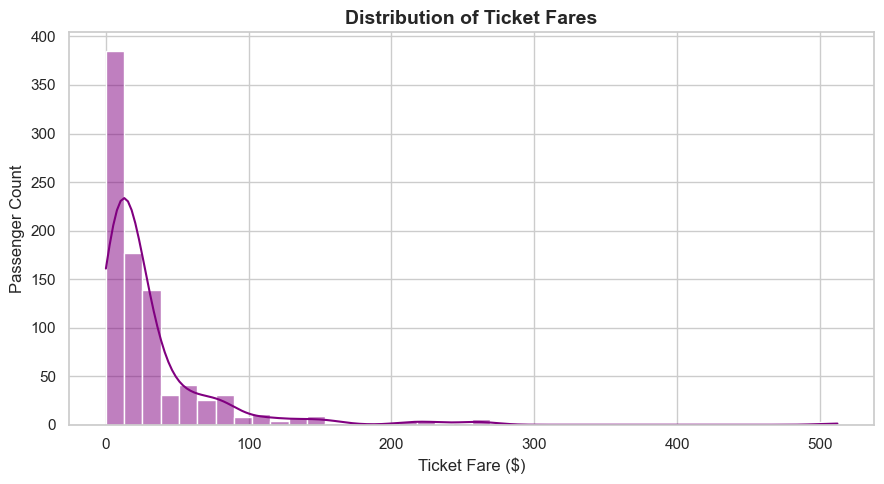

In [14]:
# Step 20: Ticket Fare Analysis (Plot 8)
print('--- Ticket Fare Description ---')
print(df['fare'].describe())

plt.figure(figsize=(9, 5))
sns.histplot(df['fare'], bins=40, kde=True, color='purple')
plt.title('Distribution of Ticket Fares', fontsize=14, fontweight='bold')
plt.xlabel('Ticket Fare ($)')
plt.ylabel('Passenger Count')
plt.tight_layout()
plt.show()


## 21. Family Relationship Analysis

The dataset contains two key family relationship columns:
- **SibSp:** Number of Siblings and Spouses aboard the Titanic.
- **Parch:** Number of Parents and Children aboard the Titanic.

By combining these columns, we can engineer a total **`family_size`** feature to analyze how traveling alone vs. traveling with family impacted survival rates.


--- First 5 rows with family_size ---


,sibsp,parch,family_size
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


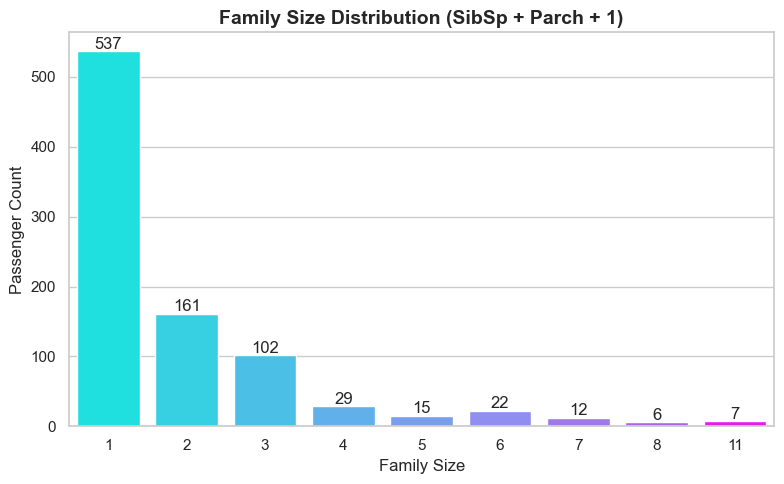

In [15]:
# Step 22: Create Family Size Feature and Plot Distribution (Plot 9)
df['family_size'] = df['sibsp'] + df['parch'] + 1

print('--- First 5 rows with family_size ---')
display(df[['sibsp', 'parch', 'family_size']].head())

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='family_size', hue='family_size', palette='cool', legend=False)
plt.title('Family Size Distribution (SibSp + Parch + 1)', fontsize=14, fontweight='bold')
plt.xlabel('Family Size')
plt.ylabel('Passenger Count')

for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


In [16]:
# Step 23: Create Clean Copy of Dataset
# We isolate raw df from df_clean so original data is preserved
df_clean = df.copy()
print('df_clean created successfully!')


df_clean created successfully!


In [17]:
# Step 24: Missing Value Handling — Age (Median Imputation)
age_null_before = df_clean['age'].isnull().sum()
median_age = df_clean['age'].median()

print(f"Missing Age values before imputation: {age_null_before}")
print(f"Calculated Median Age: {median_age:.2f}")

# Fill missing age values with median age
df_clean['age'] = df_clean['age'].fillna(median_age)

age_null_after = df_clean['age'].isnull().sum()
print(f"Missing Age values after imputation: {age_null_after}")


Missing Age values before imputation: 177
Calculated Median Age: 28.00
Missing Age values after imputation: 0


In [18]:
# Step 25: Missing Value Handling — Categorical Columns (Mode Imputation)
if 'embarked' in df_clean.columns:
    mode_embarked = df_clean['embarked'].mode()[0]
    print(f"Mode for 'embarked': {mode_embarked}")
    df_clean['embarked'] = df_clean['embarked'].fillna(mode_embarked)

if 'embark_town' in df_clean.columns:
    mode_embark_town = df_clean['embark_town'].mode()[0]
    print(f"Mode for 'embark_town': {mode_embark_town}")
    df_clean['embark_town'] = df_clean['embark_town'].fillna(mode_embark_town)

print('Categorical mode imputation complete!')


Mode for 'embarked': S
Mode for 'embark_town': Southampton
Categorical mode imputation complete!


In [19]:
# Step 26: Scikit-learn SimpleImputer Demonstration
# Demonstrate how Scikit-Learn handles missing value imputation

df_demo = df.copy()

# 1. Median Imputer for Numerical Features
num_imputer = SimpleImputer(strategy='median')
df_demo[['age']] = num_imputer.fit_transform(df_demo[['age']])
print('SimpleImputer(strategy="median") successfully imputed missing Age values!')

# 2. Most Frequent Imputer for Categorical Features
cat_imputer = SimpleImputer(strategy='most_frequent')
if 'embarked' in df_demo.columns:
    df_demo[['embarked']] = cat_imputer.fit_transform(df_demo[['embarked']])
    print('SimpleImputer(strategy="most_frequent") successfully imputed missing Embarked values!')


SimpleImputer(strategy="median") successfully imputed missing Age values!
SimpleImputer(strategy="most_frequent") successfully imputed missing Embarked values!


In [20]:
# Step 27: Handling Columns with High Missing Percentages
if 'deck' in df_clean.columns:
    deck_missing_pct = (df_clean['deck'].isnull().sum() / len(df_clean)) * 100
    print(f"'deck' column missing percentage: {deck_missing_pct:.2f}%")
    print("Since 'deck' has over 75% missing data, imputing it introduces significant synthetic noise. Dropping 'deck' column...")
    df_clean = df_clean.drop(columns=['deck'])
    print("'deck' column successfully dropped!")


'deck' column missing percentage: 77.22%
Since 'deck' has over 75% missing data, imputing it introduces significant synthetic noise. Dropping 'deck' column...
'deck' column successfully dropped!


In [21]:
# Step 28: Verify Missing Values Before vs After Cleaning
before_series = df.isnull().sum()
after_series = df_clean.isnull().sum()

comparison_df = pd.DataFrame({
    'Missing Before': before_series,
    'Missing After': after_series
}).fillna(0)

print('--- Missing Values Comparison Table ---')
display(comparison_df)


--- Missing Values Comparison Table ---


,Missing Before,Missing After
adult_male,0,0.0
age,177,0.0
alive,0,0.0
alone,0,0.0
class,0,0.0
deck,688,0.0
embark_town,2,0.0
embarked,2,0.0
family_size,0,0.0
fare,0,0.0


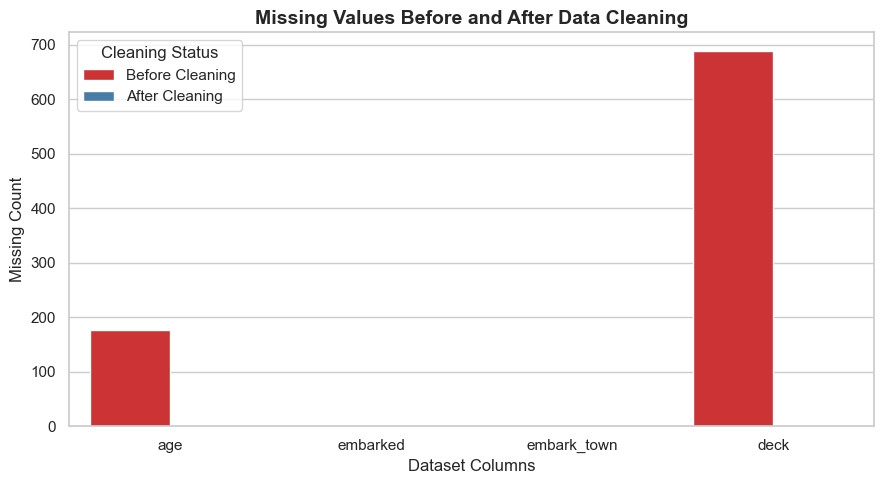

In [22]:
# Step 29: Visualization Comparing Missing Values Before vs After (Plot 10)
cols_to_compare = ['age', 'embarked', 'embark_town', 'deck']
cols_present = [c for c in cols_to_compare if c in df.columns]

comp_data = pd.DataFrame({
    'Column': cols_present,
    'Before Cleaning': [df[c].isnull().sum() for c in cols_present],
    'After Cleaning': [df_clean[c].isnull().sum() if c in df_clean.columns else 0 for c in cols_present]
}).melt(id_vars='Column', var_name='Cleaning Status', value_name='Missing Count')

plt.figure(figsize=(9, 5))
sns.barplot(data=comp_data, x='Column', y='Missing Count', hue='Cleaning Status', palette='Set1')
plt.title('Missing Values Before and After Data Cleaning', fontsize=14, fontweight='bold')
plt.xlabel('Dataset Columns')
plt.ylabel('Missing Count')
plt.tight_layout()
plt.show()


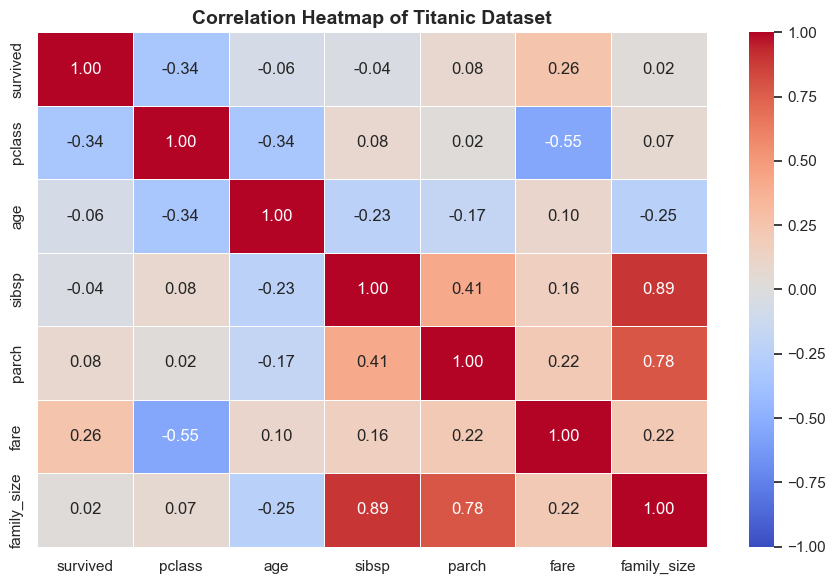

In [23]:
# Step 30: Correlation Analysis Heatmap (Plot 11)
plt.figure(figsize=(9, 6))
num_data = df_clean.select_dtypes(include=[np.number])
corr_matrix = num_data.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap of Titanic Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [24]:
# Step 31: Final Cleaned Dataset Preview and Check
print('--- Final Cleaned Dataset Preview ---')
display(df_clean.head())

print(f"\nFinal Cleaned Dataset Shape: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")
print(f"Remaining Missing Values in df_clean: {df_clean.isnull().sum().sum()}")


--- Final Cleaned Dataset Preview ---


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,1



Final Cleaned Dataset Shape: 891 rows, 15 columns
Remaining Missing Values in df_clean: 0


In [25]:
# Step 32: Save Cleaned Dataset to CSV
output_path = 'titanic_cleaned.csv'
df_clean.to_csv(output_path, index=False)
print(f"Cleaned dataset successfully exported and saved to '{output_path}'!")


Cleaned dataset successfully exported and saved to 'titanic_cleaned.csv'!


## 33. Key Findings

1. **Missing Data Profile:** The raw Titanic dataset contained missing values across `age` (177 missing), `embarked`/`embark_town` (2 missing), and `deck` (688 missing, ~77% missingness).
2. **Imputation Success:**
   - `age` missing values were successfully imputed using **Median Imputation (28.0 years)**, preserving the central tendency without sensitivity to extreme age outliers.
   - `embarked` and `embark_town` missing values were filled using **Mode Imputation ('S' / 'Southampton')**.
   - `deck` column was dropped due to excessive missingness (>75%), avoiding synthetic data distortion.
3. **Gender Survival Bias:** Female passengers had a significantly higher survival rate (~74%) compared to male passengers (~19%), confirming the historical 'women and children first' evacuation policy.
4. **Socio-Economic Class Effect:** Passengers in 1st Class enjoyed a higher survival rate (~63%) than 2nd Class (~47%) and 3rd Class (~24%), demonstrating strong correlation between fare/class and survival opportunity.
5. **Family Size Insights:** Passengers traveling with small families (family size 2–4) experienced better survival rates than solo travelers or passengers with very large families.


## 34. Academic Conclusion

In this Minor Project, we successfully explored, visualized, cleaned, and analyzed the Titanic dataset. Using structured Python workflows with Pandas, Seaborn, Matplotlib, and Scikit-Learn:
- Missing data patterns were thoroughly identified and visualized.
- Appropriate statistical imputation techniques (Median & Mode) were executed.
- Exploratory Data Analysis (EDA) revealed key demographic, survival, fare, and family relationships.
- A robust, cleaned dataset `titanic_cleaned.csv` was generated and exported for downstream analytical processing.
